In [ ]:
%pip install faiss-cpu sentence-transformers pandas numpy matplotlib

In [1]:
import pandas as pd
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import pickle
import os
import re
from typing import List, Dict, Any
import json

print("Libraries imported successfully!")
print(f"FAISS version available: {faiss.__version__ if hasattr(faiss, '__version__') else 'Unknown'}")

c:\Users\09350\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Libraries imported successfully!
FAISS version available: 1.11.0


In [2]:
DATA_PATH = r'F:\University\Year 3 Semester 1\CSS371 - NLP\Project\Data\descriptions.txt'

try:
    with open(DATA_PATH, 'r', encoding='utf-8') as f:
        raw_texts = [line.strip() for line in f if line.strip()]
    
    print(f"Successfully loaded {len(raw_texts)} lines")
    print(f"Sample lengths: {[len(text) for text in raw_texts[:5]]}")
        
except FileNotFoundError:
    print(f"File not found: {DATA_PATH}")
    print("Please check if the file exists and path is correct.")
    raw_texts = []

Successfully loaded 229 lines
Sample lengths: [331, 367, 785, 228, 184]


In [3]:
# Use whole events without chunking
print("Using whole events without chunking...")
if raw_texts:
    # ใช้ events ทั้งก้อนโดยไม่แบ่ง
    chunks = raw_texts.copy()
    
    # สร้าง metadata สำหรับ events แต่ละตัว
    metadata = []
    for doc_id, text in enumerate(chunks):
        metadata.append({
            'original_doc_id': doc_id,
            'event_id': doc_id,
            'event_length': len(text),
            'is_whole_event': True
        })
    
    print(f"Event Processing Results:")
    print(f"  Total events: {len(chunks)}")
    print(f"  Average event length: {np.mean([len(event) for event in chunks]):.0f} chars")
    print(f"  Min event length: {min([len(event) for event in chunks])} chars")
    print(f"  Max event length: {max([len(event) for event in chunks])} chars")
    
    # Show event examples
    print(f"\nEvent examples:")
    for i in range(min(3, len(chunks))):
        print(f"Event {i+1}: ({len(chunks[i])} chars)")
        print(f"  {chunks[i][:150]}...")
        print(f"  Metadata: {metadata[i]}")
        print()
else:
    chunks, metadata = [], []

Using whole events without chunking...
Event Processing Results:
  Total events: 229
  Average event length: 1013 chars
  Min event length: 6 chars
  Max event length: 3221 chars

Event examples:
Event 1: (331 chars)
  Event: Archduke Franz Ferdinand of the Austro-Hungarian Empire is assassinated in Sarajevo | Date: 1914-06-28 | Tag: assassinations, wwi | Description...
  Metadata: {'original_doc_id': 0, 'event_id': 0, 'event_length': 331, 'is_whole_event': True}

Event 2: (367 chars)
  Event: Austria-Hungary declares war on Serbia. World War I begins | Date: 1914-07-28 | Tag: declarations, invasions, wwi | Description: This is a dark...
  Metadata: {'original_doc_id': 1, 'event_id': 1, 'event_length': 367, 'is_whole_event': True}

Event 3: (785 chars)
  Event: In one month, the world erupts in war | Date: 1914-08-01 | Tag: invasions, declarations, wwi | Description: August 1st, 1914 Germany declares w...
  Metadata: {'original_doc_id': 2, 'event_id': 2, 'event_length': 785, 'is_whole_

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

if chunks:
    print(f"\nTesting embedding with first event...")
    test_embedding = model.encode([chunks[0]])
    print(f"  Embedding shape: {test_embedding.shape}")
    print(f"  Embedding sample: {test_embedding[0][:3]}...")
else:
    print("No events available for testing")

Embedding dimension: 384

Testing embedding with first event...


c:\Users\09350\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


  Embedding shape: (1, 384)
  Embedding sample: [ 0.01140315  0.03689443 -0.02484431]...


In [5]:
if chunks:
    BATCH_SIZE = 64
    all_embeddings = []
    
    for i in range(0, len(chunks), BATCH_SIZE):
        batch_events = chunks[i:i+BATCH_SIZE]
        batch_embeddings = model.encode(
            batch_events,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True  # for cosine similarity
        )
        all_embeddings.extend(batch_embeddings)
        print(f"  Processed batch {i//BATCH_SIZE + 1}/{(len(chunks)-1)//BATCH_SIZE + 1}")
    
    # Convert to numpy array
    embeddings_matrix = np.array(all_embeddings, dtype=np.float32)
    
    print(f"Embedding generation completed!")
    print(f"Embeddings matrix shape: {embeddings_matrix.shape}")
    print(f"Memory usage: ~{embeddings_matrix.nbytes / 1024 / 1024:.1f} MB")
else:
    print("No events available for embedding")
    embeddings_matrix = np.array([])

Batches: 100%|██████████| 2/2 [00:00<00:00, 21.36it/s]


  Processed batch 1/4


Batches: 100%|██████████| 2/2 [00:00<00:00, 20.62it/s]


  Processed batch 2/4


Batches: 100%|██████████| 2/2 [00:00<00:00, 14.21it/s]


  Processed batch 3/4


Batches: 100%|██████████| 2/2 [00:00<00:00, 23.75it/s]

  Processed batch 4/4
Embedding generation completed!
Embeddings matrix shape: (229, 384)
Memory usage: ~0.3 MB


In [6]:
if embeddings_matrix.size > 0:
    dimension = embeddings_matrix.shape[1]
    
    # ใช้ IndexFlatIP สำหรับ cosine similarity (เพราะ normalize ไว้แล้ว)
    index = faiss.IndexFlatIP(dimension)
    index.add(embeddings_matrix)
    
    print(f"FAISS index created successfully!")
    print(f"Dimension: {index.d}")
    print(f"Total vectors: {index.ntotal}")
    print(f"Index type: IndexFlatIP (Cosine Similarity)")
            
else:
    print("No embeddings available for indexing")
    index = None

FAISS index created successfully!
Dimension: 384
Total vectors: 229
Index type: IndexFlatIP (Cosine Similarity)


In [7]:
# Search function for events
def search_similar_events(query: str, top_k) -> List[Dict]:
    if index is None or not chunks:
        return []
    
    query_embedding = model.encode([query], normalize_embeddings=True)
    similarities, indices = index.search(query_embedding.astype(np.float32), top_k)
    
    results = []
    for similarity, idx in zip(similarities[0], indices[0]):
        if idx < len(chunks):
            result = {
                'similarity': float(similarity),
                'event_index': int(idx),
                'event_text': chunks[idx],
                'metadata': metadata[idx],
                'event_id': metadata[idx]['event_id']
            }
            results.append(result)
    
    return results

def print_event_search_results(query: str, results: List[Dict]):
    print(f"Query: '{query}'")
    print(f"Found {len(results)} events")
    
    for i, result in enumerate(results, 1):
        similarity = result['similarity']
        event_text = result['event_text']
        meta = result['metadata']
        
        print(f"\n{i}. Similarity: {similarity:.4f}")
        print(f"   Event ID: {meta['event_id']}")
        print(f"   Length: {meta['event_length']} chars")
        print(f"   Event: {event_text[:200]}{'...' if len(event_text) > 200 else ''}")

In [8]:
# Test the search function
test_queries = [
    "World War I turning points",
    "Russian Revolution",
]

for query in test_queries:
    results = search_similar_events(query, top_k=5)
    print_event_search_results(query, results)
    print("\n" + "-" * 50)

Query: 'World War I turning points'
Found 5 events

1. Similarity: 0.4922
   Event ID: 42
   Length: 475 chars
   Event: Event: The United States declares war on Germany | Date: 1917-04-06 | Tag: declarations, wwi | Description: The day after an overwhelming majority in the Senate votes for war, President Wilson signs t...

2. Similarity: 0.4603
   Event ID: 1
   Length: 367 chars
   Event: Event: Austria-Hungary declares war on Serbia. World War I begins | Date: 1914-07-28 | Tag: declarations, invasions, wwi | Description: This is a dark day and a dark hour. The sword is being forced in...

3. Similarity: 0.4448
   Event ID: 64
   Length: 355 chars
   Event: Event: President Wilson outlines his Fourteen Points | Date: 1918-01-08 | Tag: conferences, developments, wwi | Description: The peace plan includes independence for Poland, restoration of Belgian ind...

4. Similarity: 0.4303
   Event ID: 47
   Length: 356 chars
   Event: Event: The concept of Total War becomes reality | Date: 19

In [9]:
%pip install groq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from groq import Groq
import json
from typing import List, Dict, Any

groq_api_key = "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"
client = Groq(api_key=groq_api_key)

In [11]:
conversation_history = []

SYSTEM_PROMPT = """You are a knowledgeable historian and AI assistant specializing in historical events. 
You have access to a database of historical events and can provide detailed, accurate information.

Guidelines:
1. Use the provided historical context to answer questions accurately
2. If the context doesn't contain enough information, say so clearly
3. Provide specific dates, names, and details when available
4. Be educational and engaging in your responses
5. If asked about events not in the context, acknowledge the limitation
6. Always cite or reference the historical events you're discussing

Context format: Each historical event will be provided with its content and metadata."""

In [12]:
def retrieve_relevant_events(query: str, top_k: int = 3) -> List[Dict]:
    """Retrieve relevant historical events for the query"""
    try:
        # Convert query to embedding
        query_embedding = model.encode([query], normalize_embeddings=True)
        
        # Search in FAISS index
        similarities, indices = index.search(query_embedding.astype(np.float32), top_k)
        
        # Format results
        relevant_events = []
        for similarity, idx in zip(similarities[0], indices[0]):
            if idx < len(chunks) and similarity > 0.1:  # Filter low similarity
                event_data = {
                    'content': chunks[idx],
                    'similarity': float(similarity),
                    'event_id': metadata[idx]['event_id'],
                    'event_length': metadata[idx]['event_length']
                }
                relevant_events.append(event_data)
        
        return relevant_events
        
    except Exception as e:
        print(f"Error retrieving events: {e}")
        return []

In [13]:
def format_context(relevant_events: List[Dict]) -> str:
    """Format retrieved events as context for the LLM"""
    if not relevant_events:
        return "No relevant historical events found in the database."
    
    context = "Relevant Historical Events:\n\n"
    for i, event in enumerate(relevant_events, 1):
        context += f"Event {i} (Similarity: {event['similarity']:.3f}):\n"
        context += f"{event['content']}\n\n"
    
    return context

In [14]:
def generate_response(user_query: str, relevant_events: List[Dict]) -> str:
    """Generate response using Groq API with RAG context"""
    global conversation_history
    
    try:
        # Format context
        context = format_context(relevant_events)
        
        # Create messages for the conversation
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"""Context: {context}

Question: {user_query}

Please answer the question using the provided historical context. If the context doesn't contain sufficient information, please acknowledge this limitation."""}
        ]
        
        # Add conversation history (last 4 exchanges)
        if len(conversation_history) > 0:
            recent_history = conversation_history[-4:]
            for exchange in recent_history:
                messages.insert(-1, {"role": "user", "content": exchange['user']})
                messages.insert(-1, {"role": "assistant", "content": exchange['assistant']})
        
        # Call Groq API
        response = client.chat.completions.create(
            messages=messages,
            model="llama-3.3-70b-versatile",
            temperature=0.3,
            stream=False
        )
        
        answer = response.choices[0].message.content
        
        # Store in conversation history
        conversation_history.append({
            'user': user_query,
            'assistant': answer,
            'context_events': len(relevant_events),
            'timestamp': pd.Timestamp.now()
        })
        
        return answer
        
    except Exception as e:
        return f"Error generating response: {str(e)}"

In [15]:
def chat(user_query: str, show_sources: bool = True, top_k: int = 3) -> Dict:
    # Retrieve relevant events
    relevant_events = retrieve_relevant_events(user_query, top_k)
    
    # Generate response
    response = generate_response(user_query, relevant_events)
    
    # Display only the final response
    print(response)
    
    return {
        'user_query': user_query,
        'response': response,
        'relevant_events': relevant_events,
        'sources_count': len(relevant_events)
    }

In [16]:
chat("What was World War I about?", show_sources=True, top_k=5)

Error generating response: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}


{'user_query': 'What was World War I about?',
 'response': "Error generating response: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}",
 'relevant_events': [{'content': 'Event: Austria-Hungary declares war on Serbia. World War I begins | Date: 1914-07-28 | Tag: declarations, invasions, wwi | Description: This is a dark day and a dark hour. The sword is being forced into my hand. This war will demand of us enormous sacrifice in life and money, but we shall show our foes what it is to provoke Germany. Kaiser Wilhelm II, July 31, 1914',
   'similarity': 0.4605371654033661,
   'event_id': 1,
   'event_length': 367},
  {'content': 'Event: President Wilson outlines his Fourteen Points | Date: 1918-01-08 | Tag: conferences, developments, wwi | Description: The peace plan includes independence for Poland, restoration of Belgian independence, the return of Alsace-Lorraine to France, an end to secret diplomacy, autonomy of 

In [17]:
def get_conversation_history() -> List[Dict]:
    """Get conversation history"""
    global conversation_history
    return conversation_history

def clear_conversation_history():
    """Clear conversation history"""
    global conversation_history
    conversation_history = []
    print("Conversation history cleared!")

# Check if components are available
if index is not None and chunks:
    print("Historical Events ChatBot functions initialized successfully!")
    print("You can now ask questions about historical events using chat() function!")
else:
    print("Cannot initialize ChatBot - missing vector database components")

Historical Events ChatBot functions initialized successfully!
You can now ask questions about historical events using chat() function!


In [18]:
# Save and load functions
def save_vector_db(save_dir: str = "./faiss_db"):
    os.makedirs(save_dir, exist_ok=True)
    
    if index is not None and chunks:
        faiss.write_index(index, os.path.join(save_dir, "vector_index.faiss"))
    
        with open(os.path.join(save_dir, "chunks.pkl"), "wb") as f:
            pickle.dump(chunks, f)
        
        with open(os.path.join(save_dir, "metadata.pkl"), "wb") as f:
            pickle.dump(metadata, f)
        
        with open(os.path.join(save_dir, "original_texts.pkl"), "wb") as f:
            pickle.dump(raw_texts, f)
        
        config = {
            "model_name": "all-MiniLM-L6-v2",
            "embedding_dimension": embeddings_matrix.shape[1] if embeddings_matrix.size > 0 else 384,
            "total_events": len(chunks),
            "total_original_docs": len(raw_texts),
            "uses_whole_events": True,
            "no_chunking": True
        }
        
        with open(os.path.join(save_dir, "config.json"), "w") as f:
            json.dump(config, f, indent=2)
        
        print(f"Vector database saved to: {save_dir}")
        return True
    else:
        print("No data to save")
        return False

def load_vector_db(save_dir: str = "./faiss_db"):
    try:
        # โหลด FAISS index
        loaded_index = faiss.read_index(os.path.join(save_dir, "vector_index.faiss"))
        
        # โหลดข้อมูลอื่น ๆ
        with open(os.path.join(save_dir, "chunks.pkl"), "rb") as f:
            loaded_chunks = pickle.load(f)
        
        with open(os.path.join(save_dir, "metadata.pkl"), "rb") as f:
            loaded_metadata = pickle.load(f)
        
        with open(os.path.join(save_dir, "original_texts.pkl"), "rb") as f:
            loaded_original_texts = pickle.load(f)
        
        with open(os.path.join(save_dir, "config.json"), "r") as f:
            loaded_config = json.load(f)
        
        print(f"Vector database loaded from: {save_dir}")
        print(f"Config: {loaded_config}")
        
        return loaded_index, loaded_chunks, loaded_metadata, loaded_original_texts, loaded_config
    
    except Exception as e:
        print(f"Error loading vector database: {e}")
        return None, None, None, None, None

# Save the current vector database
print("Saving vector database...")
save_success = save_vector_db("./faiss_historical_db")

if save_success:
    print("\nTesting load functionality...")
    test_index, test_chunks, test_metadata, test_texts, test_config = load_vector_db("./faiss_historical_db")
    
    if test_index is not None:
        print(f"Load test successful!")
        print(f"   Index vectors: {test_index.ntotal}")
        print(f"   Events loaded: {len(test_chunks)}")
        print(f"   Original docs: {len(test_texts)}")
    else:
        print("Load test failed")

Saving vector database...
Vector database saved to: ./faiss_historical_db

Testing load functionality...
Vector database loaded from: ./faiss_historical_db
Config: {'model_name': 'all-MiniLM-L6-v2', 'embedding_dimension': 384, 'total_events': 229, 'total_original_docs': 229, 'uses_whole_events': True, 'no_chunking': True}
Load test successful!
   Index vectors: 229
   Events loaded: 229
   Original docs: 229


Creating 2D event similarity visualizations...
Creating 2D visualization of events similarity...
Running t-SNE dimensionality reduction...
Running PCA dimensionality reduction...
Running PCA dimensionality reduction...


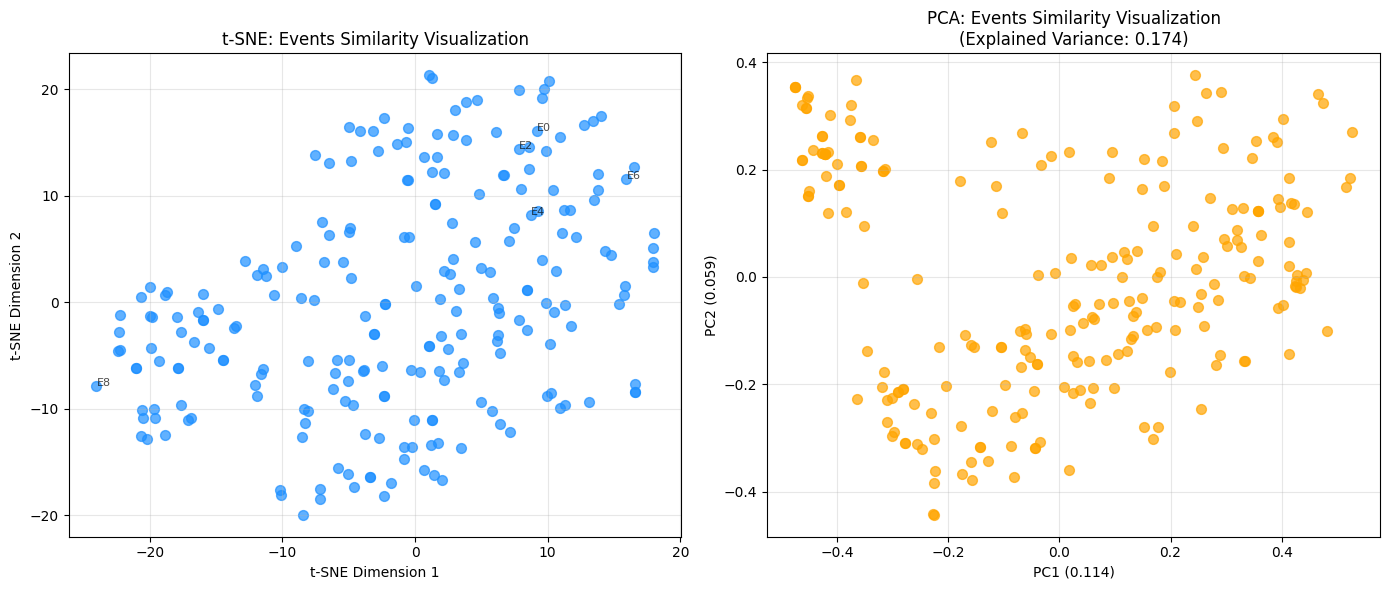

In [25]:
# 2D Visualization of Events Similarity using t-SNE and PCA (no heatmap, no color by event length)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_events_2d():
    if embeddings_matrix.size == 0:
        print("No embeddings available for visualization")
        return
    
    print("Creating 2D visualization of events similarity...")
    
    # สร้าง subplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. t-SNE visualization
    print("Running t-SNE dimensionality reduction...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(chunks)-1))
    tsne_embeddings = tsne.fit_transform(embeddings_matrix)
    
    # Plot t-SNE (ทุก event เป็นสีเดียว)
    axes[0].scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], 
                   c='dodgerblue', alpha=0.7, s=50)
    axes[0].set_title('t-SNE: Events Similarity Visualization', fontsize=12)
    axes[0].set_xlabel('t-SNE Dimension 1')
    axes[0].set_ylabel('t-SNE Dimension 2')
    axes[0].grid(True, alpha=0.3)
    
    # เพิ่ม annotation สำหรับ events บางตัว
    for i in range(0, min(10, len(chunks)), 2):
        axes[0].annotate(f'E{i}', (tsne_embeddings[i, 0], tsne_embeddings[i, 1]), 
                        fontsize=8, alpha=0.7)
    
    # 2. PCA visualization
    print("Running PCA dimensionality reduction...")
    pca = PCA(n_components=2, random_state=42)
    pca_embeddings = pca.fit_transform(embeddings_matrix)
    
    axes[1].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], 
                   c='orange', alpha=0.7, s=50)
    axes[1].set_title(f'PCA: Events Similarity Visualization\n(Explained Variance: {pca.explained_variance_ratio_.sum():.3f})', fontsize=12)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'tsne_embeddings': tsne_embeddings,
        'pca_embeddings': pca_embeddings,
        'pca_explained_variance': pca.explained_variance_ratio_.sum()
    }

print("Creating 2D event similarity visualizations...")
viz_results = visualize_events_2d()

In [35]:

def find_similar_events_in_2d(query: str, top_k: int = 10):
    if embeddings_matrix.size == 0:
        print("No embeddings available")
        return
    
    # ค้นหา similar events
    results = search_similar_events(query, top_k)
    if not results:
        print("No results found")
        return
    
    print(f"Visualizing similar events for: '{query}'")
    
    # สร้าง t-SNE และ PCA สำหรับ visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(chunks)-1))
    tsne_embeddings = tsne.fit_transform(embeddings_matrix)
    pca = PCA(n_components=2, random_state=42)
    pca_embeddings = pca.fit_transform(embeddings_matrix)
    
    # เตรียม indices และ similarity
    similar_indices = [r['event_index'] for r in results]
    similarities = [r['similarity'] for r in results]
    
    # สร้าง subplot 2 กราฟหลักคู่กัน
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # กราฟซ้าย: t-SNE
    ax1 = axes[0]
    ax1.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], 
                c='lightgray', alpha=0.3, s=30, label='Other Events')
    scatter1 = ax1.scatter(tsne_embeddings[similar_indices, 0], tsne_embeddings[similar_indices, 1],
                          c=similarities, cmap='Reds', s=100, alpha=0.8,
                          edgecolors='black', linewidths=1, label='Similar Events')
    for i, (idx, sim) in enumerate(zip(similar_indices[:5], similarities[:5])):
        ax1.annotate(f'{i+1}\n{sim:.3f}', 
                    (tsne_embeddings[idx, 0], tsne_embeddings[idx, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    ax1.set_title(f't-SNE: Similar Events\nQuery: "{query}"', fontsize=12)
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=ax1, label='Similarity Score')
    
    # กราฟขวา: PCA
    ax2 = axes[1]
    ax2.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], 
                c='lightgray', alpha=0.3, s=30, label='Other Events')
    scatter2 = ax2.scatter(pca_embeddings[similar_indices, 0], pca_embeddings[similar_indices, 1],
                          c=similarities, cmap='Reds', s=100, alpha=0.8,
                          edgecolors='black', linewidths=1, label='Similar Events')
    for i, (idx, sim) in enumerate(zip(similar_indices[:5], similarities[:5])):
        ax2.annotate(f'{i+1}\n{sim:.3f}', 
                    (pca_embeddings[idx, 0], pca_embeddings[idx, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    ax2.set_title(f'PCA: Similar Events\nExplained Variance: {pca.explained_variance_ratio_.sum():.3f}', fontsize=12)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=ax2, label='Similarity Score')
    
    plt.tight_layout()
    plt.show()


Testing search-based visualization...

Demo: 'World War I battles'
Visualizing similar events for: 'World War I battles'


c:\Users\09350\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


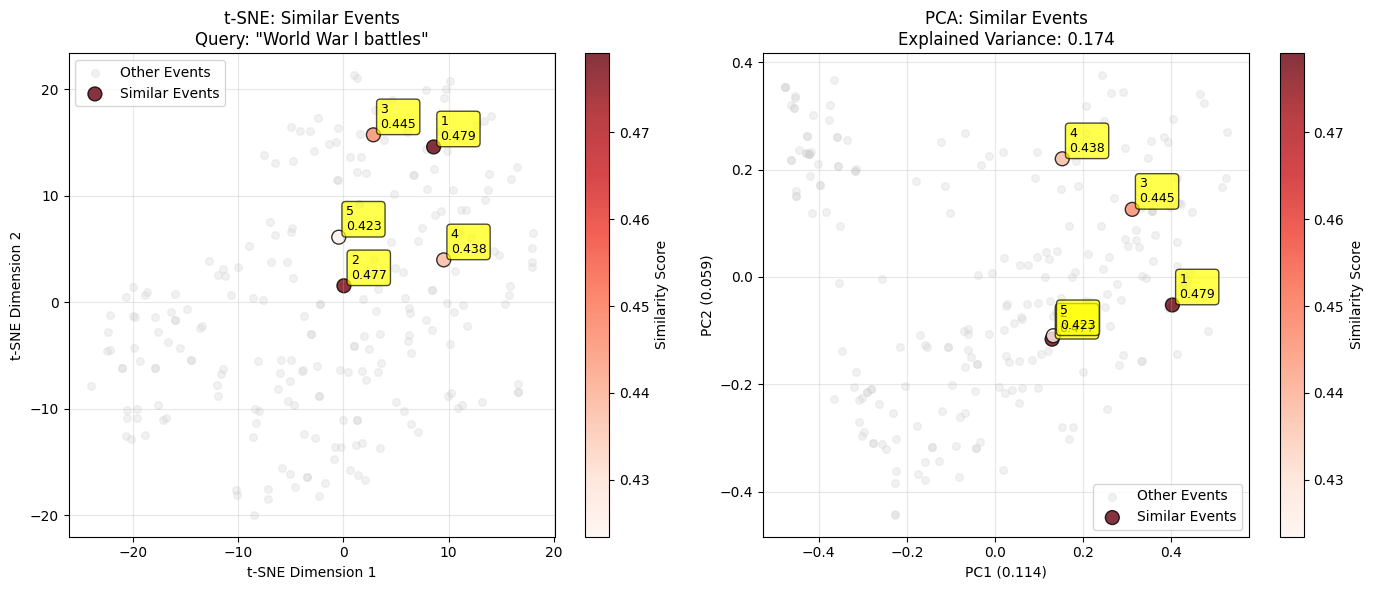


Demo: 'Russian Revolution 1917'
Visualizing similar events for: 'Russian Revolution 1917'


c:\Users\09350\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1747: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


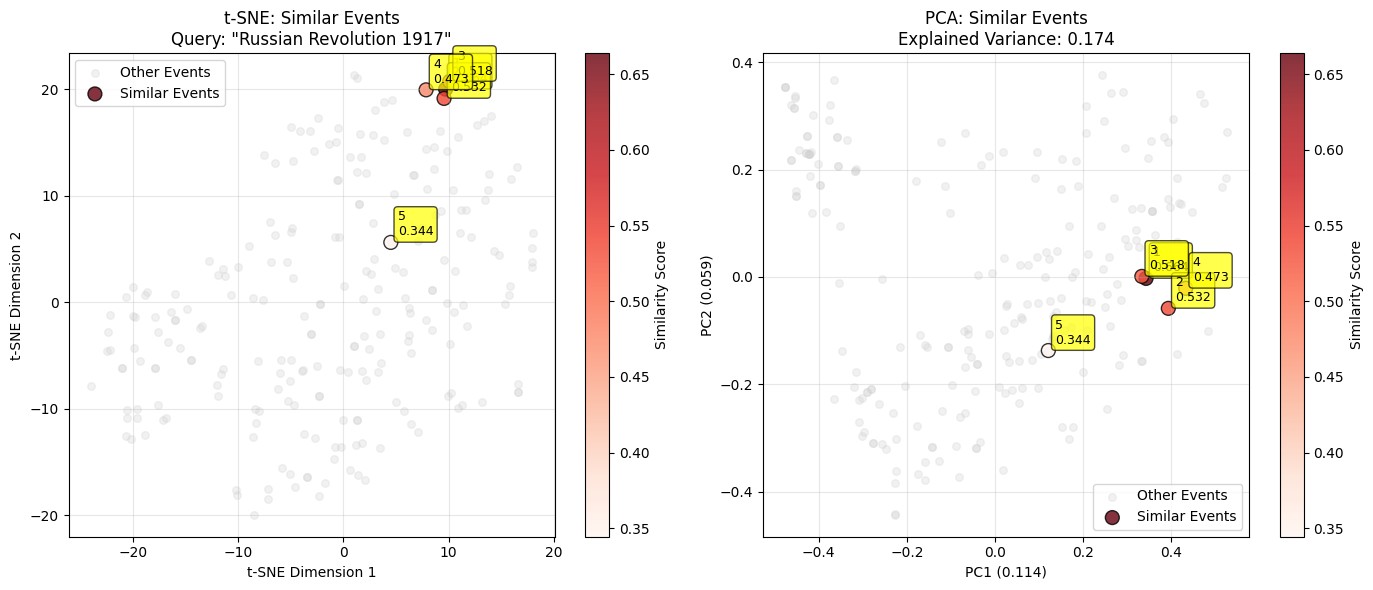

In [36]:
# Demo: Search and visualize specific historical topics
print("\nTesting search-based visualization...")

demo_queries = [
    "World War I battles",
    "Russian Revolution 1917", 
    "Treaty negotiations",
    "Military strategies"
]

for query in demo_queries[:2]: 
    if chunks:
        print(f"\nDemo: '{query}'")
        find_similar_events_in_2d(query, top_k=5)
    else:
        print(f"Cannot demo '{query}' - no events loaded")
        break